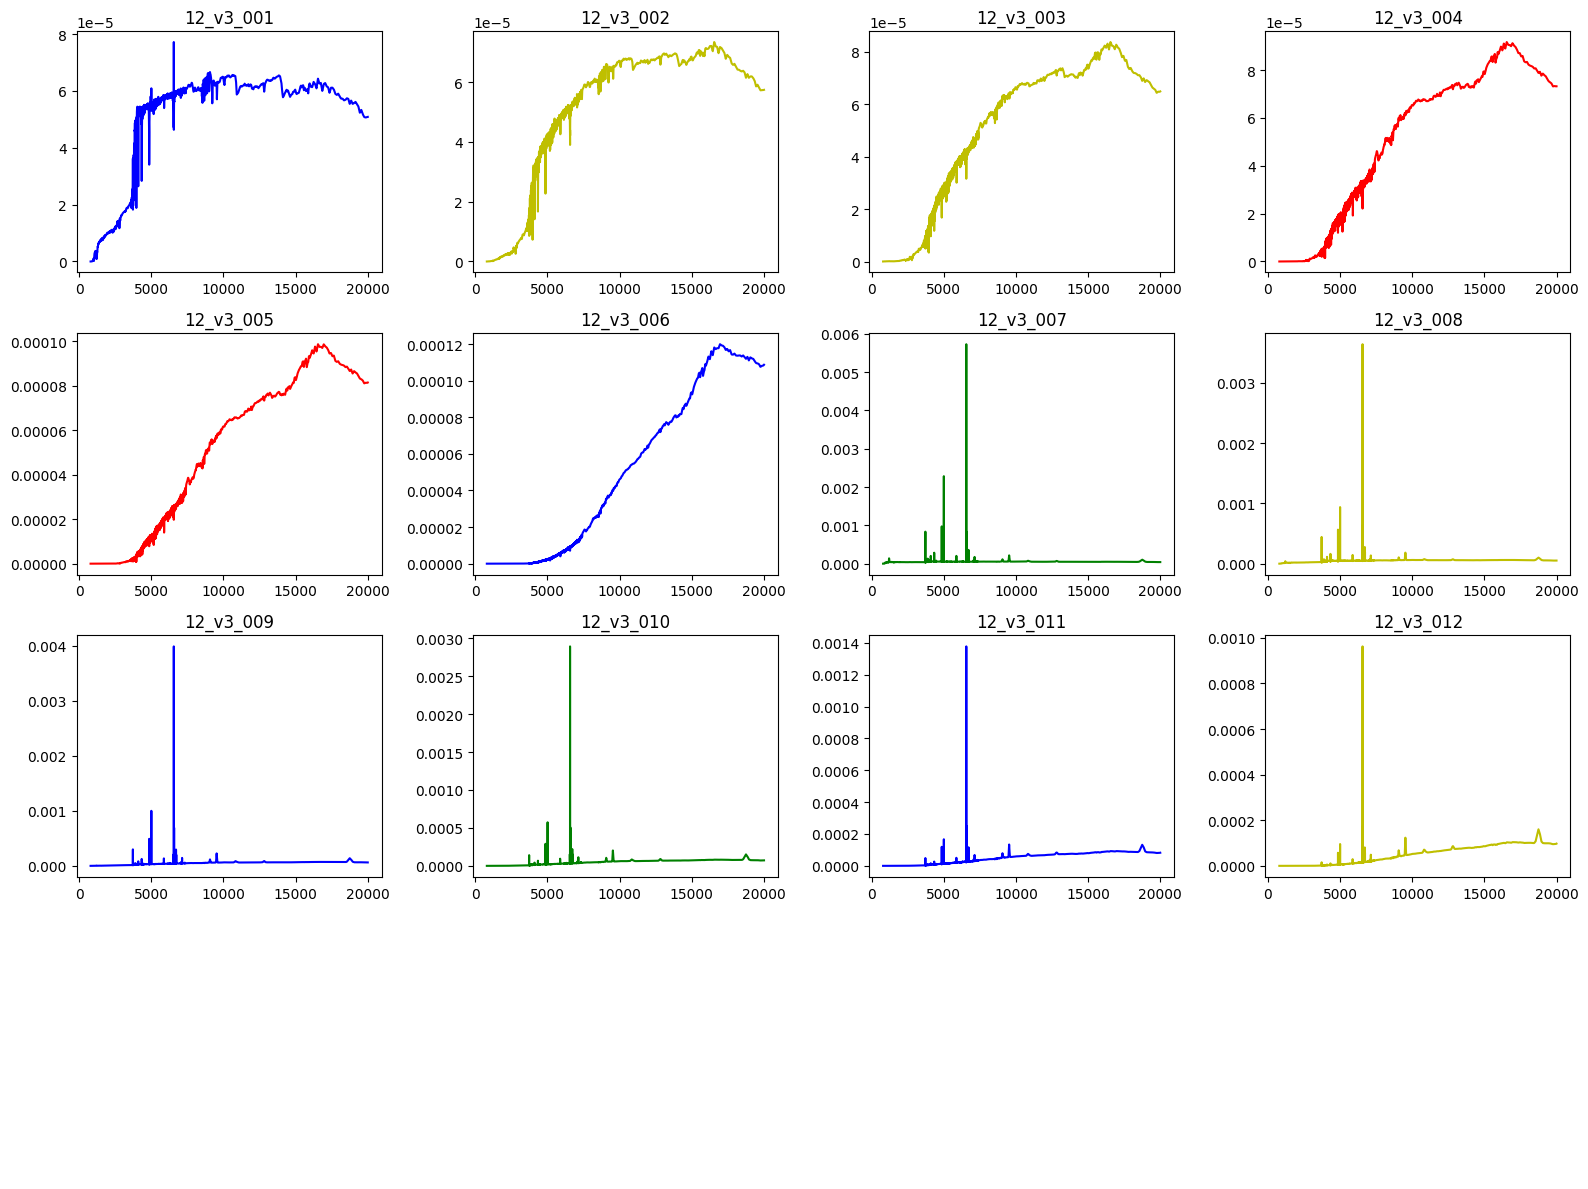

In [13]:
import numpy as np
from glob import glob
import matplotlib.pyplot as plt

# Files
files = glob('fsps/*')

# Common wavelength grid (uniform in λ)
wave_grid = np.linspace(800, 20000, 10000)
dlam = np.gradient(wave_grid)   # needed for proper L1

# Storage
flux_interp_L1 = {}

# Plot setup
fig, axes = plt.subplots(4, 4, figsize=(16, 12))
axes = axes.flatten()
colors = ['r', 'b', 'g', 'y']

for idx, fname in enumerate(files):
    # Load
    wave, flux = np.loadtxt(fname, unpack=True)

    # Convert Fλ → Fν
    flux = flux * wave**2 / 3e18

    # Interpolate FIRST
    flux_interp = np.interp(wave_grid, wave, flux)
    
    # L1 normalization (area = 1)
    area = np.sum(flux_interp * dlam)
    flux_L1 = flux_interp / (area)
    # Store
    flux_interp_L1[fname] = flux_L1

    # Plot
    ax = axes[idx]
    ax.plot(wave_grid, flux_L1, color=np.random.choice(colors))
    ax.set_title(fname[-13:-4])

# Turn off unused panels
for idx in range(len(files), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()


In [46]:
flux_list = []
for name in flux_interp_L1.keys():
    flux_list.append(flux_interp_L1[name])

X = np.array(flux_list)

In [49]:
from sklearn.decomposition import NMF
model = NMF(4, init='random', random_state=0)
W = model.fit_transform(X)
H = model.components_

C:\Users\pranav\AppData\Roaming\Python\Python312\site-packages\sklearn\decomposition\_nmf.py:1759: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


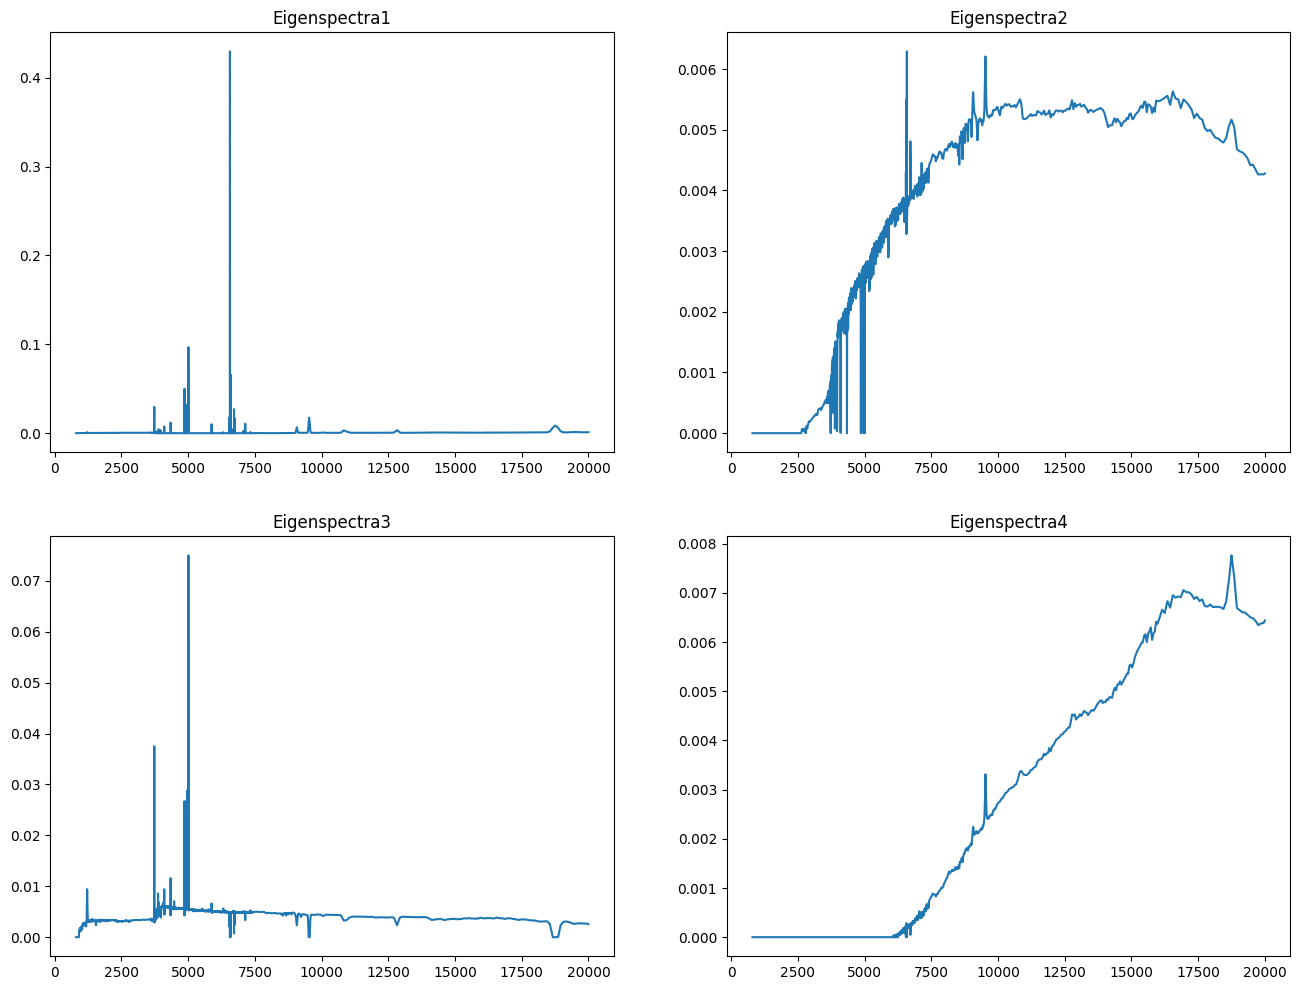

In [50]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

axs=axes.flatten()
for i in range(len(H)):
    ax = axs[i]
    ax.plot(wave_grid, H[i])
    ax.set_title(f'Eigenspectra{i+1}')

C:\Users\pranav\AppData\Roaming\Python\Python312\site-packages\sklearn\decomposition\_nmf.py:1759: ConvergenceWarning: Maximum number of iterations 800 reached. Increase it to improve convergence.
  warnings.warn(
C:\Users\pranav\AppData\Roaming\Python\Python312\site-packages\sklearn\decomposition\_nmf.py:1759: ConvergenceWarning: Maximum number of iterations 800 reached. Increase it to improve convergence.
  warnings.warn(
C:\Users\pranav\AppData\Roaming\Python\Python312\site-packages\sklearn\decomposition\_nmf.py:1759: ConvergenceWarning: Maximum number of iterations 800 reached. Increase it to improve convergence.
  warnings.warn(
C:\Users\pranav\AppData\Roaming\Python\Python312\site-packages\sklearn\decomposition\_nmf.py:1759: ConvergenceWarning: Maximum number of iterations 800 reached. Increase it to improve convergence.
  warnings.warn(
C:\Users\pranav\AppData\Roaming\Python\Python312\site-packages\sklearn\decomposition\_nmf.py:1759: ConvergenceWarning: Maximum number of iterati

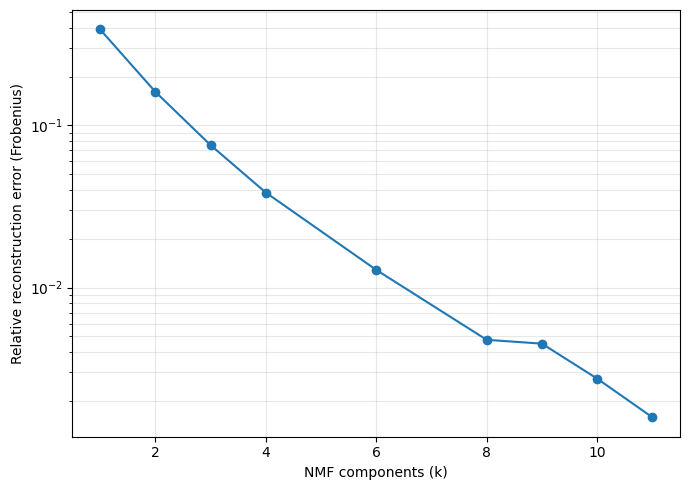

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import NMF

# X = (n_templates, n_wave) non-negative
X = np.array(X, dtype=np.float32)
X[X < 0] = 0.0

# Try a small set of k values first (log-ish spacing)
k_list = np.array([1, 2, 3, 4, 6, 8, 9,10,11])
k_list = k_list[k_list < min(X.shape)]  # can't exceed min(n_templates, n_wave)

errs = []

for k in k_list:
    model = NMF(
        n_components=int(k),
        init="nndsvda",
        solver="cd",
        beta_loss="frobenius",
        max_iter=800,      # keep modest
        tol=1e-4,          # relax tolerance a bit
        random_state=0
    )
    W = model.fit_transform(X)
    H = model.components_
    Xhat = W @ H

    rel_err = np.linalg.norm(X - Xhat, ord="fro") / (np.linalg.norm(X, ord="fro") + 1e-30)
    errs.append(rel_err)

errs = np.array(errs)

plt.figure(figsize=(7,5))
plt.plot(k_list, errs, marker="o")
plt.xlabel("NMF components (k)")
plt.ylabel("Relative reconstruction error (Frobenius)")
plt.yscale("log")
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()


In [26]:
errs

array([0.39043591, 0.16107893, 0.0755935 , 0.03854657, 0.01285572,
       0.00476414])